# Extended Data Figure 1 — longitudinal blood samples pre-AML diagnosis

This notebook reproduces the three panels of **Extended Data Figure 1**:

- **a** — timings of UKCTOCS blood samples relative to AML diagnosis.
- **b** — distribution of age at AML diagnosis (mean 72, range 53–83, s.d. 6 years).
- **c** — distribution of DNA yields for pre-AML (red) and control (blue) serum samples.

## Data availability

The input file is **individual-level participant data** and is **not distributed with this code**

| file (in `Data_files/`, not publicly distributed) | used for |
|---|---|
| `UKCTOCS_samples_processed_information.csv` | sample timings, ages at diagnosis, DNA yields |

This panel summarises the study's sampling design; the sample-level values are individual-level and available under controlled access, deposited in the European Genome-phenome Archive (EGA) and released to approved researchers via a Data Access Committee administered by the corresponding authors. With the file present in `Data_files/`, the notebook runs top to bottom and reproduces the published figure.

## 1. Imports and colours

In [1]:
# import packages
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import csv
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']

grey2, grey3 = '#cccccc', '#969696'
blue4, red4 = '#3182bd', '#de2d26'
c2 = (1.00, 0.23, 0.19)   # pre-AML red (panel a)

## 2. Load UKCTOCS sample information

In [2]:
def convert_to_year_range(years):
    if 0 < years < 0.5:
        year_interval = 0.25
    elif 0.5 <= years < 1:
        year_interval = 0.75
    else:
        year_interval = int(years)+0.5
    
    return -year_interval

In [3]:
#create a dictionary of the sample details
cases = {} #e.g. {'C92_002': ['C92_002_s1', 'C92_002_s2', 'C92_002_s3', 'C92_002_s4'....]}
controls = {} #e.g. {'CNTRL_001': ['CNTRL_001_s1', 'CNTRL_001_s10', 'CNTRL_001_s2'...]}
cases_and_controls = {}
sample_ages = {} #e.g. {'C92_002_s1': 73.., 'C92_002_s2': 75.., 'C92_002_s3': 75......}
sample_diagnosis_age = {} #e.g. {'C92_002': 81.., 'C92_003': 75.., 'C92_005': 70.....}
sample_DNA_yield = {}
sample_DNA_amount = {} #e.g. {'C92_002_s1': '45', 'C92_002_s2': '50', 'C92_002_s3': '50'...}
matched_sample = {} #e.g. {'C92_002': 'CNTRL_169', 'C92_003': 'CNTRL_002'...}
time_to_diagnosis = {}
time_to_spin = {}
DNA_sequenced = []

with open('Data_files/UKCTOCS_samples_processed_information.csv') as csvfile:
    readreader = csv.reader(csvfile)
    row_count=0
    for row in readreader:
        if row_count>0:
            sample_name = row[1].split('_')[0]+'_'+row[1].split('_')[1]
            timepoint = row[1]
            sample_ages[timepoint]=float(row[8])
            sample_DNA_amount[timepoint]=row[4]
            sample_DNA_yield[timepoint]=float(row[3])
            time_to_spin[timepoint]=float(row[2])
            pre_diagnosis = row[5]
            if row[9]!='':
                if '_' in row[9]:
                    matched_sample_name = row[9].split('_')[0]+'_'+row[9].split('_')[1]
                    matched_sample[sample_name]=matched_sample_name
                else:
                    matched_sample[sample_name]=row[9]
                    
            if sample_name in cases_and_controls.keys():
                cases_and_controls[sample_name].append(timepoint)
            else:
                cases_and_controls[sample_name]=[timepoint]
                    
            if row[0]=='Case':
                DNA_sequenced.append(float(row[4]))
                if sample_name in cases.keys():
                    cases[sample_name].append(timepoint)
                else:
                    cases[sample_name]=[timepoint]
                    
                sample_diagnosis_age[sample_name]=float(row[7])
                
                years_pre_diagnosis_interval = convert_to_year_range(float(pre_diagnosis)/12)
                
                if sample_name in time_to_diagnosis.keys():
                    time_to_diagnosis[sample_name].append(years_pre_diagnosis_interval)
                else:
                    time_to_diagnosis[sample_name]=[years_pre_diagnosis_interval]
                
            if row[0]=='Control':
                if sample_name in controls.keys():
                    controls[sample_name].append(timepoint)
                else:
                    controls[sample_name]=[timepoint]
                if sample_name in matched_sample.keys():
                    sample_diagnosis_age[sample_name]=sample_diagnosis_age[matched_sample[sample_name]]

        row_count+=1
        
cases_and_controls_sorted = {}
for k, v in cases_and_controls.items():
    ages_sorted = []
    for i in v:
        timepoint_number = int(i.split('_')[2][1:])
        ages_sorted.append((timepoint_number, i))
    sorted_v = sorted(ages_sorted, reverse = False)
    cases_and_controls_sorted[k]=[]
    for i in sorted_v:
        cases_and_controls_sorted[k].append(i[1])

In [4]:
sorted_times_to_diagnosis = {}
for k, v in time_to_diagnosis.items():
    sorted_times = sorted(v)
    sorted_times_to_diagnosis[k]=[len(sorted_times), sorted_times, sample_diagnosis_age[k], matched_sample[k]]

sorted_times_to_diagnosis_length = {k: v for k, v in sorted(sorted_times_to_diagnosis.items(), key=lambda item: item[1])}

## 3. Panel a — sample timings relative to AML diagnosis

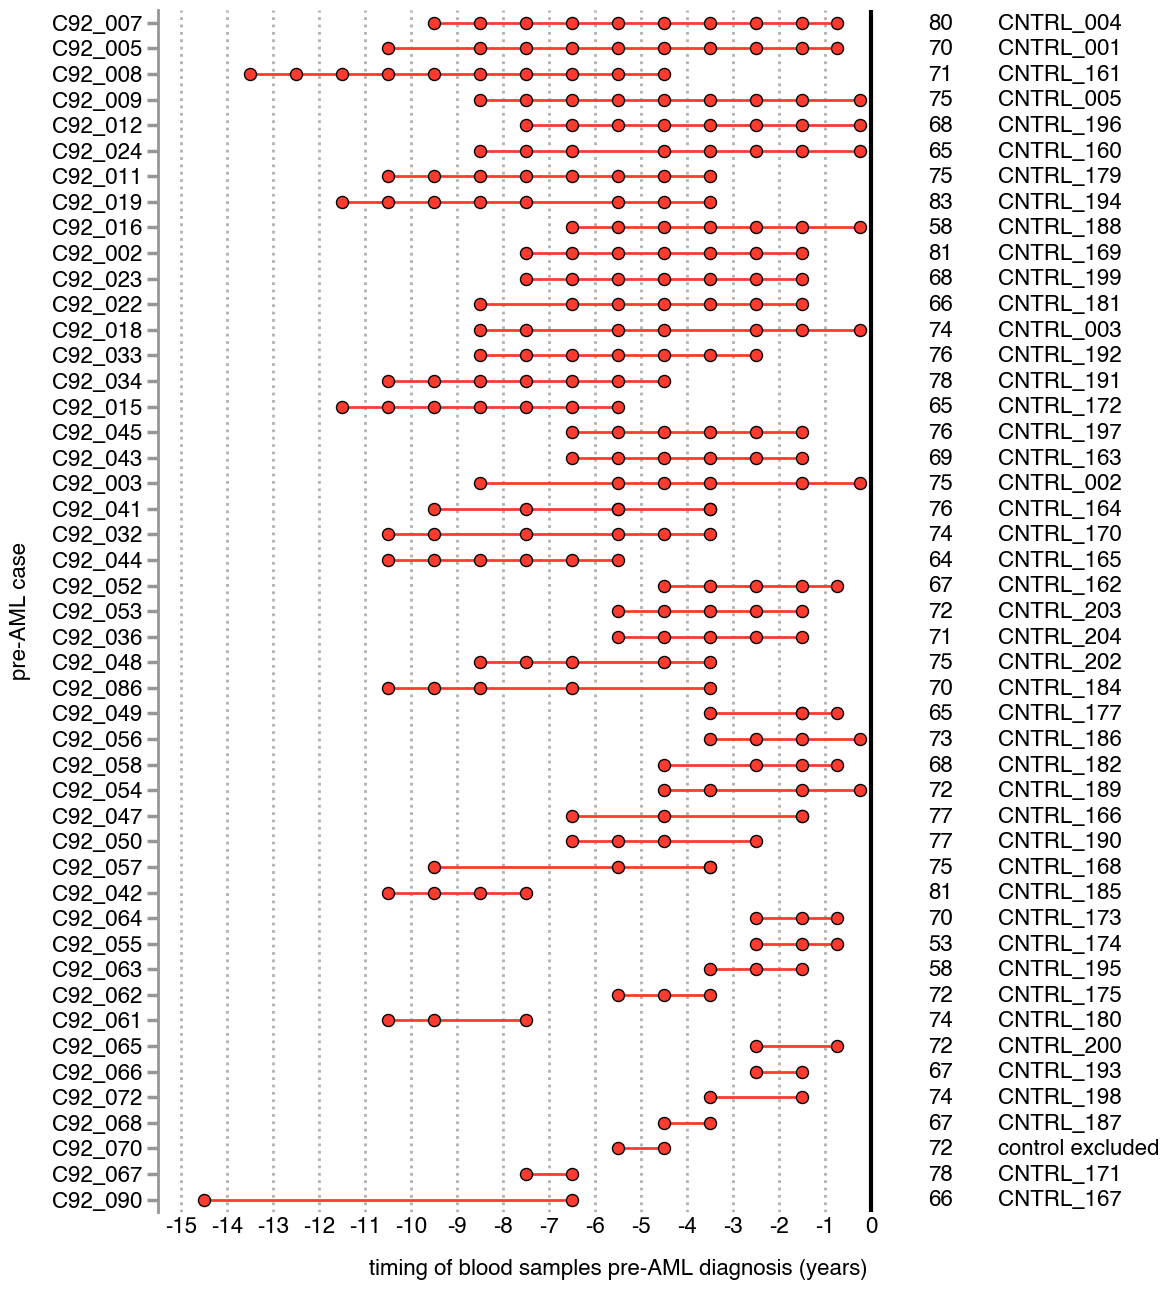

total samples =  249


In [5]:
# Plots of C920 (Acute Myeloid Leukaemia)
plt.close('all')
fig, (ax1) = plt.subplots(1, 1, sharey=True,figsize=(11.8, 13))

helvetica_6 = 16
m_size=75
zo=1
zo1=2
w=1.5
height=0

#plot the diagnosis line
x0=[0 for i in range(-10,222)]
y0=[i for i in range(-10,222)]
ax1.plot(x0,y0, color='k', linewidth=3, alpha=1, zorder=4)

total_samples = 0
samples_per_person = []
diagnosis_ages = []

#plot the sample time-points
n = 1
for sample_name, timings in sorted_times_to_diagnosis_length.items():
    years = timings[1]
    diagnosis_age = timings[2]
    diagnosis_ages.append(diagnosis_age)
    matched_control = timings[3]
    y = [sample_name for i in range(0, len(years))]
#     print(n)
#     print(years)
    total_samples_each_person = 0
    for year in years:
        total_samples+=1
        total_samples_each_person+=1
        ax1.scatter(year, sample_name, color = c2, edgecolor = 'k', s = m_size, zorder = 10)
    ax1.plot(years, y, color = c2, lw = 2)
    ax1.annotate(str(int(diagnosis_age)), xy = (1.5, sample_name), xytext = (0, -1), textcoords = 'offset points', fontsize = helvetica_6, ha = 'center', va = 'center')
    ax1.annotate(matched_control, xy = (2.75, sample_name), xytext = (0, -1), textcoords = 'offset points', fontsize = helvetica_6, ha = 'left', va = 'center')
    samples_per_person.append(total_samples_each_person)
    n+=1
    
#set the axis limits
ax1.set_xlim(-15.5,4.5)
ax1.set_ylim(-0.5,46.5)

#x-axis ticks
x_major_ticks = [-15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0]        
x_major_tick_labels = ["-15", "-14", "-13", "-12", "-11", "-10", "-9", "-8", "-7", "-6", "-5", "-4", "-3", "-2", "-1", "0"]

ax1.set_xticks(x_major_ticks)
ax1.set_xticklabels(x_major_tick_labels, fontsize = 14)
ax1.xaxis.grid(True, linewidth=2,linestyle=':',which='major')
# ax1.xaxis.set_tick_params(labeltop='on')

#Only show the required axis lines
for axis in ['bottom', 'top', 'right']:
    ax1.spines[axis].set_visible(False)

ax1.spines['left'].set_linewidth(2)
ax1.spines['left'].set_color(grey3)
ax1.yaxis.set_tick_params(width=2.5, color = grey3, length = 8, which = 'major', labelsize=helvetica_6)
ax1.xaxis.set_tick_params(width=0, color = grey3, length = 0, which = 'major', labelsize=helvetica_6)


#Title and axis labels
# ax1.set_title('C92.0 cases: Acute Myeloid Leukaemia', y=1.01, fontsize = titlefont, fontweight='bold')
ax1.set_xlabel('timing of blood samples pre-AML diagnosis (years)', fontsize = helvetica_6)
ax1.xaxis.labelpad = 15
ax1.set_ylabel('pre-AML case', fontsize = helvetica_6)
ax1.yaxis.labelpad = 15

plt.yticks(fontsize = helvetica_6)
plt.xticks(fontsize = helvetica_6)

plt.tight_layout()
plt.show()

print('total samples = ', total_samples)

## 4. Panel b — distribution of age at AML diagnosis

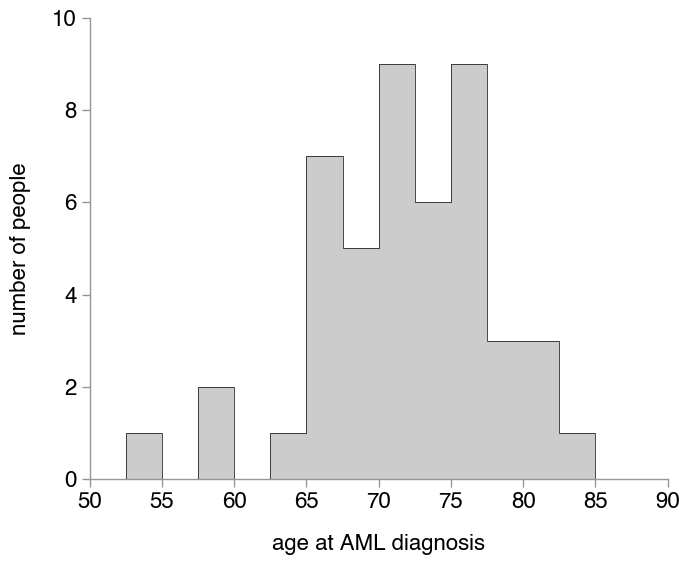

total samples =  249


In [6]:
# Plot of distribution of age at diagnosis
plt.close('all')
fig, (ax1) = plt.subplots(1, 1, sharey=True,figsize=(7, 5.75))

helvetica_6 = 16
m_size=75
zo=1
zo1=2
w=1.5
height=0

diagnosis_ages = []
for sample_name, diagnosis_age in sample_diagnosis_age.items():
    if 'C92' in sample_name:
        diagnosis_ages.append(diagnosis_age)

ax1.hist(diagnosis_ages, bins = np.arange(50, 90, 2.5), color = grey2, linewidth = 0.5)
ax1.hist(diagnosis_ages, histtype='step', bins = np.arange(50, 90, 2.5), color = 'black', linewidth = 0.5)
    
#set the axis limits
ax1.set_xlim(50, 90)
ax1.set_ylim(0, 10)

#Only show the required axis lines
for axis in ['top', 'right']:
    ax1.spines[axis].set_visible(False)

for axis in ['left', 'bottom']:
    ax1.spines[axis].set_linewidth(1)
    ax1.spines[axis].set_color(grey3)
ax1.yaxis.set_tick_params(width=1, color = grey3, length = 6, which = 'major', labelsize=helvetica_6)
ax1.xaxis.set_tick_params(width=1, color = grey3, length = 6, which = 'major', labelsize=helvetica_6)


#Title and axis labels
# ax1.set_title('C92.0 cases: Acute Myeloid Leukaemia', y=1.01, fontsize = titlefont, fontweight='bold')
ax1.set_xlabel('age at AML diagnosis', fontsize = helvetica_6)
ax1.xaxis.labelpad = 15
ax1.set_ylabel('number of people', fontsize = helvetica_6)
ax1.yaxis.labelpad = 15

plt.yticks(fontsize = helvetica_6)
plt.xticks(fontsize = helvetica_6)

plt.tight_layout()
plt.show()

print('total samples = ', total_samples)

## 5. Panel c — distribution of DNA yields

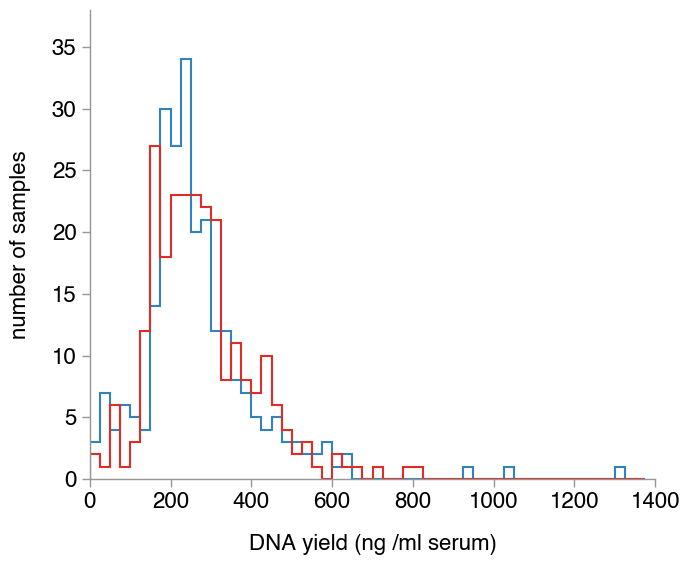

total samples =  249
mean DNA yield in pre-AMLs =  278.6755020080322
mean DNA yield in controls =  270.0133603238866


In [7]:
# Plot of distribution of DNA yields
plt.close('all')
fig, (ax1) = plt.subplots(1, 1, sharey=True,figsize=(7, 5.75))

helvetica_6 = 16
m_size=75
zo=1
zo1=2
w=1.5
height=0

case_DNA_yields = []
control_DNA_yields = []

for sample_name, DNA_yield in sample_DNA_yield.items():
    if 'C92' in sample_name:
        case_DNA_yields.append(DNA_yield)
    else:
        control_DNA_yields.append(DNA_yield)

ax1.hist(control_DNA_yields, histtype='step', bins = np.arange(0, 1400, 25), color = blue4, linewidth = 1.5)
ax1.hist(case_DNA_yields, histtype='step', bins = np.arange(0, 1400, 25), color = red4, linewidth = 1.5)
    
#set the axis limits
ax1.set_xlim(0, 1400)
ax1.set_ylim(0, 38)

#Only show the required axis lines
for axis in ['top', 'right']:
    ax1.spines[axis].set_visible(False)

for axis in ['left', 'bottom']:
    ax1.spines[axis].set_linewidth(1)
    ax1.spines[axis].set_color(grey3)
ax1.yaxis.set_tick_params(width=1, color = grey3, length = 6, which = 'major', labelsize=helvetica_6)
ax1.xaxis.set_tick_params(width=1, color = grey3, length = 6, which = 'major', labelsize=helvetica_6)


#Title and axis labels
# ax1.set_title('C92.0 cases: Acute Myeloid Leukaemia', y=1.01, fontsize = titlefont, fontweight='bold')
ax1.set_xlabel('DNA yield (ng /ml serum)', fontsize = helvetica_6)
ax1.xaxis.labelpad = 15
ax1.set_ylabel('number of samples', fontsize = helvetica_6)
ax1.yaxis.labelpad = 15

plt.yticks(fontsize = helvetica_6)
plt.xticks(fontsize = helvetica_6)

plt.tight_layout()
plt.show()

print('total samples = ', total_samples)
print('mean DNA yield in pre-AMLs = ', np.mean(case_DNA_yields))
print('mean DNA yield in controls = ', np.mean(control_DNA_yields))

## 6. Summary statistics (quoted in the figure legend / text)

In [8]:
#samples
q3, q1 = np.percentile(samples_per_person, [75 ,25])
iqr = q3 - q1

print('median number of samples per person = ', np.median(samples_per_person))
print('maximum number of samples per person = ', max(samples_per_person))
print('interquartile range of number of samples per person = ', iqr)

median number of samples per person =  5.0
maximum number of samples per person =  10
interquartile range of number of samples per person =  3.5


In [9]:
#AML diagnosis
q3, q1 = np.percentile(diagnosis_ages, [75 ,25])
iqr = q3 - q1
print('iqr=',iqr)
print('s.d.=', np.std(diagnosis_ages))

print('mean age at diagnosis of AML = ', np.mean(diagnosis_ages))
print('median age at diagnosis of AML = ', np.median(diagnosis_ages))
print('minimum age at diagnosis of AML = ', min(diagnosis_ages))
print('maximum age at diagnosis of AML = ', max(diagnosis_ages))
print('interquartile range for age at diagnosis of AML = ', iqr)

number_of_timepoints = []
for case, samples in cases.items():
    number_of_timepoints.append(len(samples))

print('median number of timepoints = ', np.median(number_of_timepoints))
print('minimum number of timepoints = ', min(number_of_timepoints))
print('maximum number of timepoints = ', max(number_of_timepoints))
q3, q1 = np.percentile(number_of_timepoints, [75 ,25])
iqr = q3 - q1
print('interquartile range for number of timepoints = ', iqr)

sum(number_of_timepoints)

iqr= 7.739999999999995
s.d.= 6.081794635188566
mean age at diagnosis of AML =  71.7668085106383
median age at diagnosis of AML =  72.29
minimum age at diagnosis of AML =  53.0
maximum age at diagnosis of AML =  83.96
interquartile range for age at diagnosis of AML =  7.739999999999995
median number of timepoints =  5.0
minimum number of timepoints =  2
maximum number of timepoints =  10
interquartile range for number of timepoints =  3.5


249